S&P Profitability (2/8/13) to (2/7/18)

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [55]:
sp500 = yf.download('^GSPC',start = '2013-2-8', end = '2018-2-7')

[*********************100%***********************]  1 of 1 completed


In [56]:
firstDayOpen = (sp500['Open'].iloc[0]).item()
lastDayClose = sp500['Close'].iloc[-1].item()
overallProfitPercent = round(((lastDayClose-firstDayOpen)/firstDayOpen)*100,2)
overallProfitPercent

78.56

In [57]:
sectorPerformance = pd.read_csv('Stock_Profitability_Data_Raw.csv')
sectorPerformance = sectorPerformance.head(11)
sectorPerformance

,Sector,Average of Overall_Profit_2013_2018
0,Communication Services,99.0
1,Consumer Discretionary,93.0
2,Consumer Staples,72.0
3,Energy,12.0
4,Financials,78.0
5,Health Care,108.0
6,Industrials,90.0
7,Information Technology,165.0
8,Materials,126.0
9,Real Estate,74.0


In [58]:
sectorPerformance['Growth_Relative_to_S&P'] = sectorPerformance['Average of Overall_Profit_2013_2018'] - (overallProfitPercent)
sectorPerformance

,Sector,Average of Overall_Profit_2013_2018,Growth_Relative_to_S&P
0,Communication Services,99.0,20.44
1,Consumer Discretionary,93.0,14.44
2,Consumer Staples,72.0,-6.56
3,Energy,12.0,-66.56
4,Financials,78.0,-0.56
5,Health Care,108.0,29.44
6,Industrials,90.0,11.44
7,Information Technology,165.0,86.44
8,Materials,126.0,47.44
9,Real Estate,74.0,-4.56


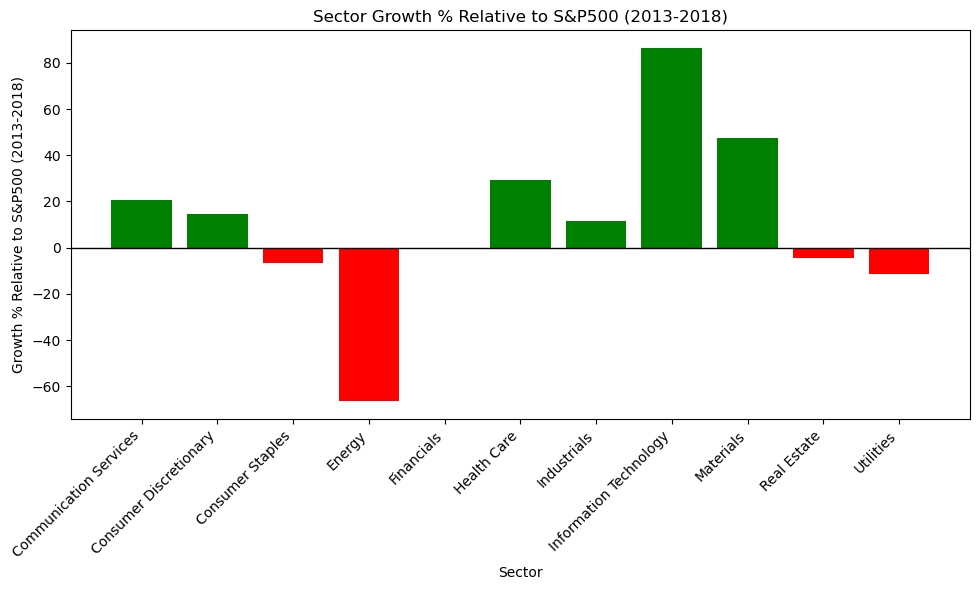

In [75]:
growth = sectorPerformance["Growth_Relative_to_S&P"]

# Green for positive, red for negative
colors = ["green" if value >= 0 else "red" for value in growth]

plt.figure(figsize=(10,6))
plt.bar(
    sectorPerformance["Sector"],
    growth,
    color=colors
)

plt.title("Sector Growth % Relative to S&P500 (2013-2018)")
plt.xlabel("Sector")
plt.ylabel("Growth % Relative to S&P500 (2013-2018)")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, color="black", linewidth=1)  
plt.tight_layout()
plt.savefig("sector_growth.png", dpi=300, bbox_inches="tight")
plt.show()
